#Open AI Gym

OpenAI Gym (now often referred to as Gymnasium) is an open-source Python toolkit for developing, comparing, and testing reinforcement learning (RL) algorithms. It provides a standardized API and a diverse collection of simulation environments from classic control tasks to Atari games that allow AI agents to learn through trial-and-error

# Frozen Lake Gymnasium Environment

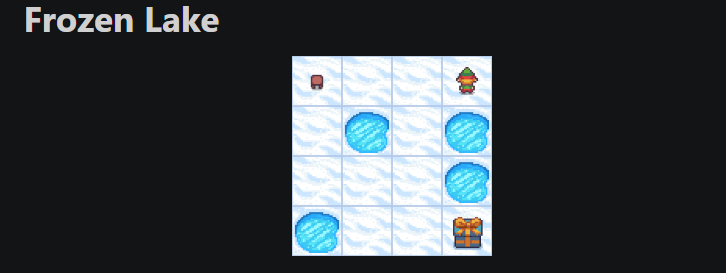

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

# Description

The game starts with the player at location [0,0] of the frozen lake grid world with the goal located at far extent of the world e.g. [3,3] for the 4x4 environment.

Holes in the ice are distributed in set locations when using a pre-determined map or in random locations when a random map is generated. Randomly generated worlds will always have a path to the goal.

The player makes moves until they reach the goal or fall in a hole.

The lake is slippery (unless disabled) so the player may move perpendicular to the intended direction sometimes (see is_slippery in Argument section).

In [35]:
!pip install gymnasium

In [36]:
# import main library
import gymnasium as gym



In [37]:
# create environment for training agent

'''
allows to automatically load environments,
pre-wrapped with several important wrappers
'''
env = gym.make('FrozenLake-v1',render_mode='rgb_array')

In [38]:
print(env.observation_space.n)#get number of states
print(env.action_space.n)#get number of actions

16
4


Action space, possible actions the agent can take in each state

0: Move left

1: Move down

2: Move right

3: Move up

Observation is a state(he actual piece of information the environment provides to your agent at a specific moment in time. It's an instance or a snapshot from the observation_space.)

In essence, observation_space.n tells you how many distinct situations or positions the agent can perceive in the environment.

In [39]:
env.reset()# retruns agent to starting position

(0, {'prob': 1})

In [40]:
# randomly samples an action
action = env.action_space.sample()
print(action)

0


In [41]:
# new_state: The agent's new observation/state after taking the action.
# reward: The reward received after taking the action.
# terminated: True if the episode ended because the agent reached a terminal state (goal or hole).
# truncated: True if the episode ended prematurely (e.g., time limit reached).
# info: A dictionary containing auxiliary diagnostic information.
new_state, reward, terminated,truncated,info = env.step(action)

In [42]:
print(new_state)

0


# Slippery

The 'slippery' nature of the Frozen Lake environment means that when your agent chooses an action (e.g., 'move right'), there's a probability that it might not move in that intended direction. Instead, it might move perpendicular to it (e.g., up or down, if the intended action was right). This introduces an element of randomness and challenge, as the agent cannot always perfectly control its movement, even if it selects the 'correct' action.

array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
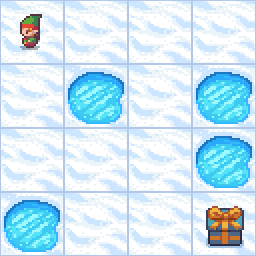

In [43]:
# visualize the environment
env.render()

To visualize the environment, you need to re-initialize it by specifying a `render_mode` during creation. `rgb_array` is a good choice for getting an image representation of the environment, which can then be displayed.

In [44]:
import matplotlib.pyplot as plt

def visualize():

# Render the environment
  rendered_image = env.render()
# Display the image
  plt.imshow(rendered_image)
  plt.axis('off') # Hide axes for a cleaner look
  plt.show()

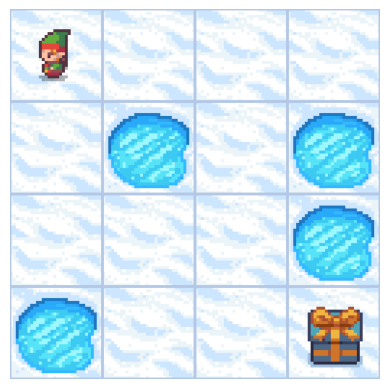

In [45]:
visualize()

In [46]:
env.close()

# Building Q-Table



In [47]:
import numpy as np

ACTIONS = env.action_space.n
STATES = env.observation_space.n

Q_TABLE = np.zeros((STATES,ACTIONS))
print(Q_TABLE)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Understanding the Q-Table

The essence of building a Q-table is to create a lookup table that helps an agent learn the optimal actions to take in different states of an environment to maximize its cumulative reward. Here's a breakdown:

1.  **What it is:** A Q-table (or Q-function table) is a matrix where rows represent states and columns represent actions. Each cell `Q(state, action)` stores a value (Q-value) that estimates the expected future reward an agent will receive if it takes `action` in `state` and then follows an optimal policy afterward.

2.  **Purpose:** Its main goal is to guide the agent's decision-making. During training, the agent explores the environment, performs actions, observes rewards, and updates these Q-values. Over time, the Q-values converge to represent the maximum expected future reward for taking a particular action in a given state.

3.  **Initialization:** Typically, a Q-table is initialized with zeros (as you've done with `np.zeros`). This reflects the agent's initial ignorance about the environment.

4.  **Learning/Update:** Through repeated trials (episodes), the agent updates the Q-values using the Bellman equation, which incorporates the immediate reward and the estimated future rewards from the next state. The agent learns by exploring (trying new actions) and exploiting (choosing actions with higher Q-values).



# Creating constants

In [48]:
EPISODES = 5000 # number of times the agent gets to train
MAX_STEPS = 300 #the number of time an agent gets to make a move in a single episode

LEARNING_RATE = 0.81 #how much update should be included
GAMMA = 0.96 #how much weight to attacj=h on future rewards

# threshold until agent starts making its own decesions based on the Q-table

EPSILON_START = 1.0
MIN_EPSILON = 0.01
EPSILON_DECAY_RATE = (EPSILON_START - MIN_EPSILON) / EPISODES

## Explaining the Q-Learning Constants

These constants are crucial hyperparameters that govern the behavior and learning process of our Q-learning agent:

*   **`EPISODES` (10000)**:
    *   **Importance:** This is the total number of training iterations or "games" the agent will play and learn from. A higher number of episodes generally allows the agent more opportunities to explore the environment, experience different scenarios, and refine its Q-values, leading to a more robust policy. However, too many episodes can lead to overfitting or unnecessarily long training times.

*   **`MAX_STEPS` (100)**:
    *   **Importance:** This defines the maximum number of actions the agent can take within a single episode before that episode is considered "truncated" (ended prematurely). It's a safety mechanism to prevent episodes from running indefinitely, especially in environments where the agent might get stuck in a loop or fail to reach a terminal state. It ensures that the agent keeps exploring new episodes even if it struggles to solve the current one.

*   **`LEARNING_RATE` or Alpha (α) (0.81)**:
    *   **Importance:** This hyperparameter determines how much new information overrides old information in the Q-value update. A high learning rate (close to 1) means the agent heavily weighs new experiences, potentially leading to faster learning but also instability. A low learning rate (close to 0) makes the agent rely more on past experiences, leading to slower but potentially more stable convergence. It's a balance between quickly adapting to new information and maintaining knowledge from previous experiences.

*   **`GAMMA` or Discount Factor (γ) (0.96)**:
    *   **Importance:** The discount factor determines the importance of future rewards. A value closer to 1 (like 0.96) means the agent considers future rewards almost as important as immediate rewards. This encourages the agent to prioritize long-term gains. A value closer to 0 would make the agent more short-sighted, focusing only on immediate rewards. In many environments, a high gamma is desirable for finding optimal long-term strategies.

In [49]:
'''
probability value thats allows for agent exploration and exploitation
exploration happens during earlier episodes allowing agent taking random actions(figuring out environment)
exploitation at later episodes when it has a confident understanding of the environment
uses knowldge to select maximum action that leads to maximum reward
'''

epsilon = 0.9


# exploration phase

# generates a single random floating-point number between 0 (inclusive) and 1 (exclusive)
if np.random.uniform(0, 1) < epsilon:
    action = env.action_space.sample()

#exploitation phase
#select the best action - maximum reward
else:
    action = np.argmax(Q_TABLE[STATES, :])

# Updating Q_Table

```Q[state, action] = Q[state, action] + LEARNING_RATE * (reward + GAMMA * max(Q[new_state, :]) - Q[state, action])```



*   `Q[s, a]`: The current Q-value for the state-action pair.
*   `α` (LEARNING_RATE): How much new information is accepted (between 0 and 1).
*   `r` (reward): Immediate reward received after taking action `a`.
*   `γ` (GAMMA): Discount factor for future rewards (between 0 and 1).
*   `max(Q[s', :])`: The maximum Q-value from the next state `s'`, representing the best possible future reward.
*   `(r + γ * max(Q[s', :]) - Q[s, a])`: The 'Temporal Difference (TD) error' – the difference between the new estimate of the total reward and the old estimate.

**In essence:** The formula adjusts the current Q-value by a fraction of the TD error, moving it closer to a more accurate estimate of the expected total discounted reward.

In [50]:
RENDER = True #to visually observe training

# Training agent



In [130]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)

In [131]:
EPISODES = 5000 # number of times the agent gets to train
MAX_STEPS = 100 #the number of time an agent gets to make a move in a single episode

LEARNING_RATE = 0.81 #how much update should be included
GAMMA = 0.96 #how much weight to attacj=h on future rewards

# threshold until agent starts making its own decesions based on the Q-table

EPSILON_START = 0.9
MIN_EPSILON = 0.01
ACTIONS = env.action_space.n
STATES = env.observation_space.n

Q_TABLE = np.zeros((STATES,ACTIONS))


In [132]:
epsilon = EPSILON_START
rewards = []
for episode in range(EPISODES):

  # at the begginning of each episode agent is at the same position
  state = env.reset()[0]


  # MOVING THROUGH THE ENVIRONMENT

  for _ in range(MAX_STEPS):

    # select action

    if np.random.uniform(0,1) < epsilon:
      action = env.action_space.sample() #select a random action

    else:
      action = np.argmax(Q_TABLE[state, :]) #select best action

    # agent takes an action

    next_state, reward, terminated, truncated, _ = env.step(action)



    # Updating Q_Table

    Q_TABLE[state, action] = Q_TABLE[state, action] + LEARNING_RATE * (reward + GAMMA * np.max(Q_TABLE[next_state, :]) - Q_TABLE[state, action])

    state = next_state #update agents position

    if terminated or truncated:
      rewards.append(reward)
      epsilon = max(0.01, epsilon - 0.001)
      break # when goal is reached or when hole is encountered move







# Agents perfomance

In [133]:
average_rewards = sum(rewards) / len(rewards)
print(average_rewards)

0.8972


# Testing Agent in a simulated environment

# Agents Training Perfomance

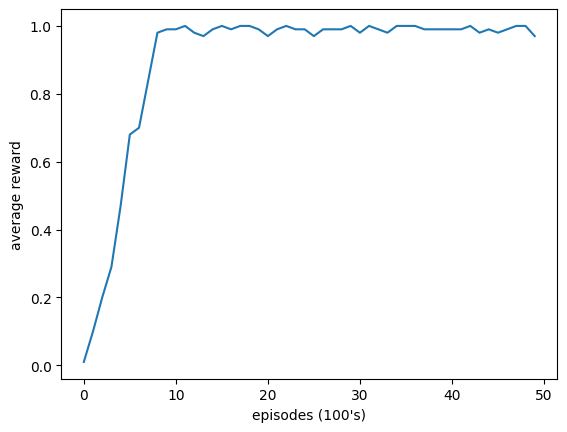

In [141]:
import matplotlib.pyplot as plt

def get_average(values):
  return sum(values)/len(values)

avg_rewards = []
for i in range(0, len(rewards), 100):
  avg_rewards.append(get_average(rewards[i:i+100]))

plt.plot(avg_rewards)
plt.ylabel('average reward')
plt.xlabel('episodes (100\'s)')
plt.show()

In [142]:
len(rewards)

5000